In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok = True)
os.makedirs("tables", exist_ok = True)

In [2]:
def save_latex(df, filename):
    df.to_latex(filename, index = False, float_format = "%.6f")

def split_table(df, name):
    mid = len(df)//2

    left = df.iloc[:mid]
    right = df.iloc[mid:]

    left.to_latex(f"tables/{name}_left.tex", index = False, float_format = "%.6f")
    right.to_latex(f"tables/{name}_right.tex", index = False, float_format = "%.6f")

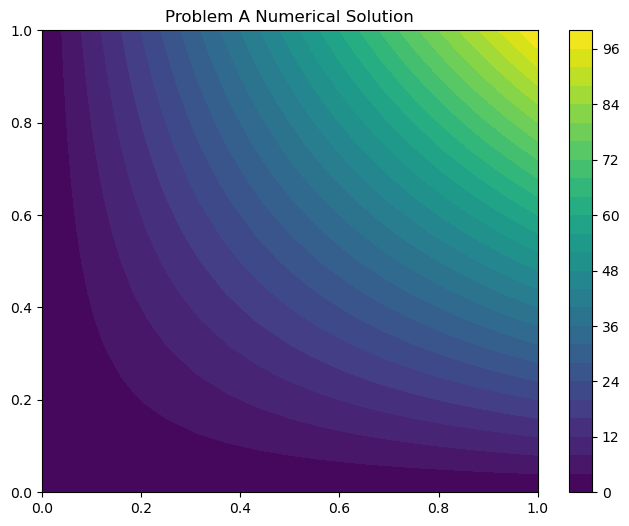

In [3]:
#Problem A:

def solve_laplace(N,tol=1e-10):

    h = 1/N

    x = np.linspace(0,1,N+1)
    y = np.linspace(0,1,N+1)

    U = np.zeros((N+1,N+1))

    U[:,N] = 100*x
    U[N,:] = 100*y

    error = 1

    while error > tol:

        old = U.copy()

        for i in range(1,N):
            for j in range(1,N):

                U[i,j] = 0.25*(U[i+1, j]+U[i-1, j]+U[i, j+1]+U[i, j-1])

        error = np.max(np.abs(U-old))

    X,Y = np.meshgrid(x,y,indexing = 'ij')

    exact = 100*X*Y

    return x,y,U,exact


x,y,U,exact = solve_laplace(16)

tableA = pd.DataFrame({
    "x":x,
    "Numerical":U[:,8],
    "Exact":exact[:,8],
    "Error":np.abs(U[:,8]-exact[:,8])
})

split_table(tableA,"problem_a_table")

plt.figure(figsize = (8,6))
plt.contourf(x,y,U.T,levels = 30)
plt.colorbar()
plt.title("Problem A Numerical Solution")
plt.savefig("figures/problem_a_graph.png", dpi = 300)
plt.show()

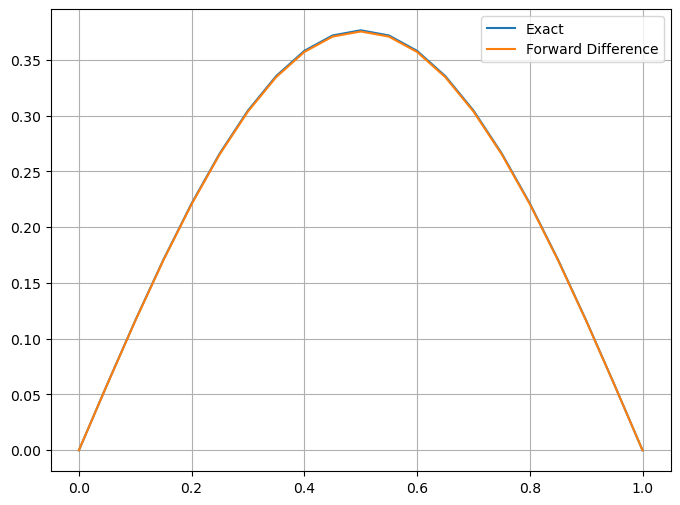

In [4]:
#Problem B:

def forward_heat(h,lam,T):

    k = lam*h**2

    x = np.arange(0,1+h,h)

    M = len(x)-1

    nsteps = int(T/k)

    U = np.sin(np.pi*x)

    for n in range(nsteps):

        Unew = U.copy()

        for i in range(1,M):

            Unew[i] = U[i]+lam*(U[i+1]-2*U[i]+U[i-1])

        U = Unew

    t = nsteps*k

    exact = np.exp(-np.pi**2*t)*np.sin(np.pi*x)

    return x, U, exact


x,Uf,exact = forward_heat(0.05,0.4,0.1)

tableB = pd.DataFrame({"x":x, "Exact":exact, "Forward":Uf, "Error":np.abs(exact-Uf)})

tableB_display = tableB.iloc[::2]

split_table(tableB_display,"problem_b_table")

plt.figure(figsize = (8,6))
plt.plot(x,exact,label = "Exact")
plt.plot(x,Uf,label = "Forward Difference")
plt.legend()
plt.grid()
plt.savefig("figures/problem_b_graph.png",dpi = 300)
plt.show()

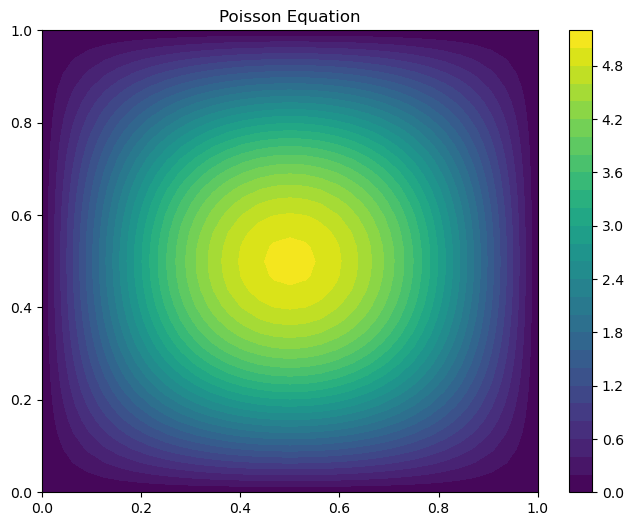

In [5]:
#Problem C1:

def solve_poisson(N,tol = 1e-10):

    h = 1/N

    x = np.linspace(0,1,N+1)
    y = np.linspace(0,1,N+1)

    X,Y = np.meshgrid(x,y,indexing = 'ij')

    U = np.zeros((N+1,N+1))

    f = -100*np.sin(np.pi*X)*np.sin(np.pi*Y)

    exact = (50/(np.pi**2))*np.sin(np.pi*X)*np.sin(np.pi*Y)

    error = 1

    while error > tol:

        old = U.copy()

        for i in range(1,N):
            for j in range(1,N):

                U[i,j] = 0.25*(U[i+1,j]+U[i-1,j]+U[i,j+1]+U[i,j-1]-h**2*f[i,j])

        error = np.max(np.abs(U-old))

    return x,y,U,exact


x,y,U,exact = solve_poisson(32)

tableC1 = pd.DataFrame({"x":x, "Numerical":U[:,16], "Exact":exact[:,16], "Error":np.abs(U[:,16]-exact[:,16])})

split_table(tableC1,"problem_c1_table")

plt.figure(figsize = (8,6))
plt.contourf(x,y,U.T,levels = 30)
plt.colorbar()
plt.title("Poisson Equation")
plt.savefig("figures/problem_c1_graph.png",dpi = 300)
plt.show()

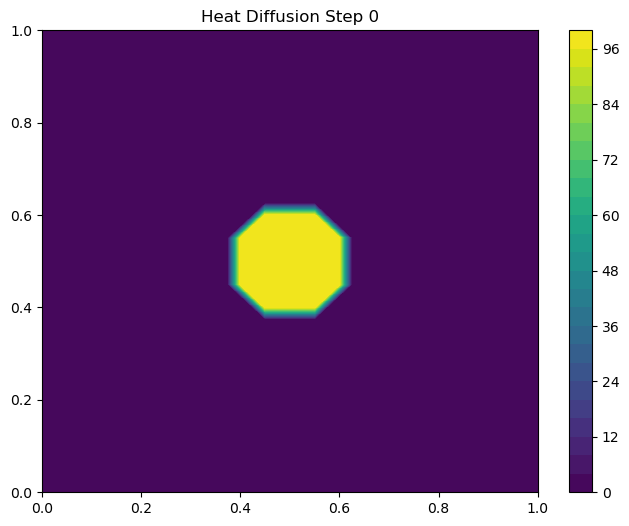

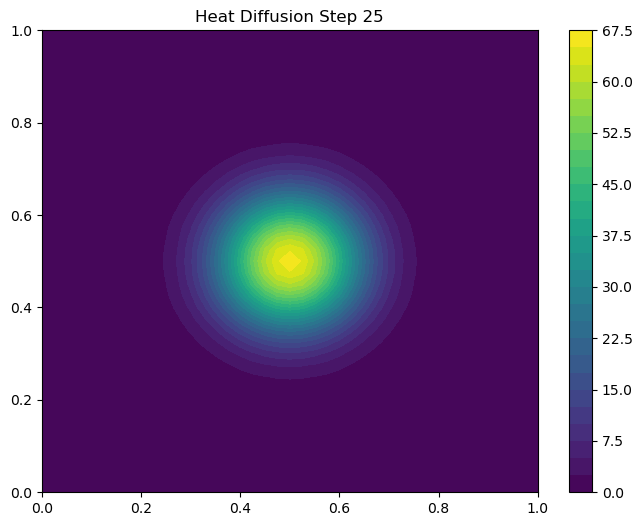

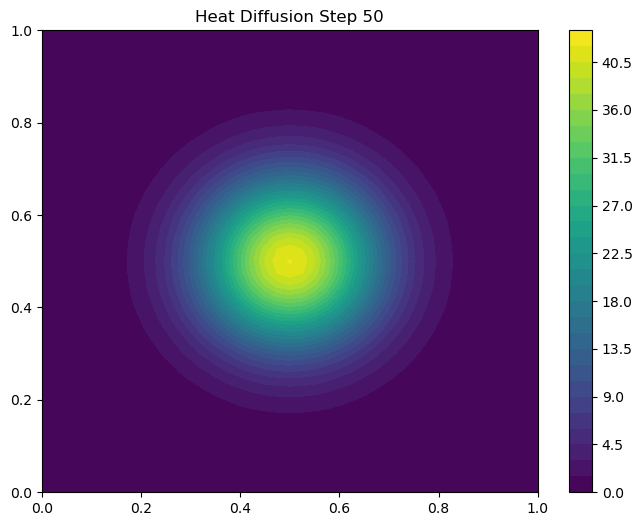

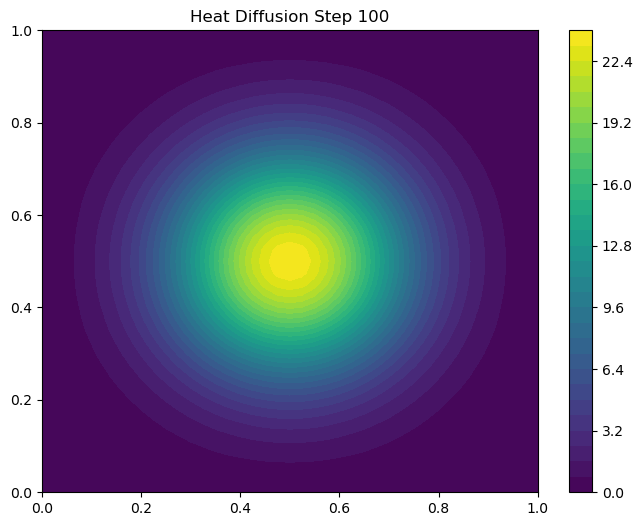

In [6]:
#Problem C2:

N = 40

h = 1/N

lam = 0.2

k = lam*h**2

steps = 100

x = np.linspace(0,1,N+1)
y = np.linspace(0,1,N+1)

X,Y = np.meshgrid(x,y,indexing = 'ij')

U = np.zeros((N+1,N+1))

U[(X-0.5)**2 + (Y-0.5)**2 <= 0.12**2] = 100

snapshots = []

for n in range(steps+1):

    if n in [0,25,50,100]:
        snapshots.append((n,U.copy()))

    Unew = U.copy()

    for i in range(1,N):
        for j in range(1,N):

            Unew[i,j] = U[i,j] + lam*(U[i+1,j]+U[i-1,j]+U[i,j+1]+U[i,j-1]-4*U[i,j])

    U = Unew

for n,Ushot in snapshots:

    plt.figure(figsize = (8,6))

    plt.contourf(x, y, Ushot.T, levels = 30)

    plt.colorbar()

    plt.title(f"Heat Diffusion Step {n}")

    plt.savefig(f"figures/problem_c2_step_{n}.png", dpi = 300)

    plt.show()